# 01 — Exploratory Data Analysis
Deep dive into the heart disease dataset before any modeling.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/heart.csv')
print(df.shape)
df.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,66,M,ATA,178,147,1,LVH,152,Y,2.7,Flat,1
1,56,M,ASY,92,210,0,Normal,184,N,1.7,Down,0
2,42,M,ASY,190,252,0,LVH,98,N,5.5,Up,0
3,70,M,ATA,177,222,1,Normal,63,N,0.3,Up,0
4,35,M,ASY,90,201,0,ST,185,N,5.7,Down,1


## 1. Basic Info

In [2]:
df.info()
print('\nNull values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Null values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak 

In [3]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Age,918.000000,52.259259,14.107714,28.000000,40.000000,53.000000,64.000000,76.000000
RestingBP,918.000000,139.847495,34.742465,80.000000,109.000000,138.500000,171.000000,199.000000
Cholesterol,918.000000,255.752723,87.441389,100.000000,180.000000,255.500000,329.000000,409.000000
FastingBS,918.000000,0.212418,0.409242,0.000000,0.000000,0.000000,0.000000,1.000000
MaxHR,918.000000,130.469499,41.569333,60.000000,92.000000,131.000000,165.000000,201.000000
Oldpeak,918.000000,2.964488,1.761754,0.000000,1.500000,2.900000,4.400000,6.200000
HeartDisease,918.000000,0.505447,0.500243,0.000000,0.000000,1.000000,1.000000,1.000000


## 2. Target Distribution

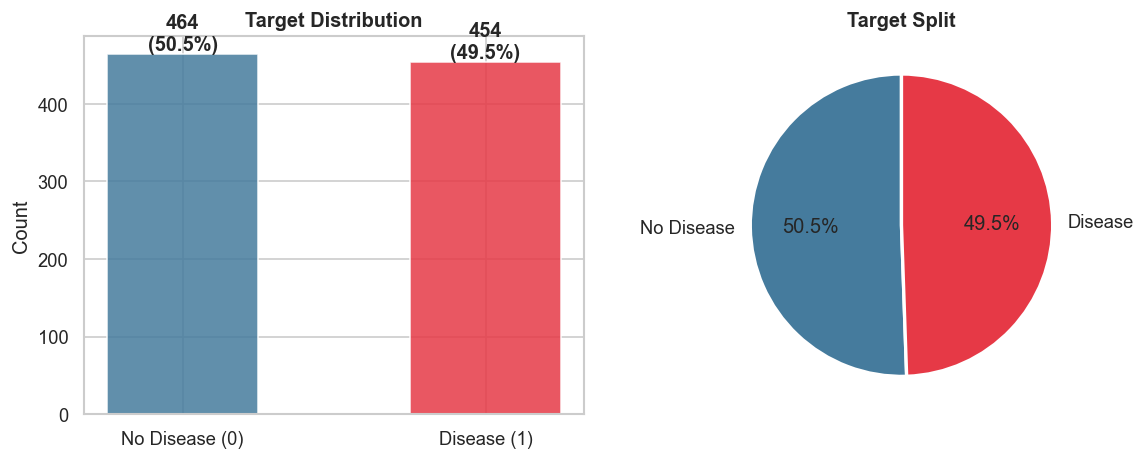

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['HeartDisease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#457b9d', '#e63946'], alpha=0.85, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            colors=['#457b9d', '#e63946'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Split', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Numerical Features Distribution

C:\Users\elssh\AppData\Local\Temp\ipykernel_28936\2098066175.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][i].boxplot(data_to_plot, patch_artist=True,
C:\Users\elssh\AppData\Local\Temp\ipykernel_28936\2098066175.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][i].boxplot(data_to_plot, patch_artist=True,
C:\Users\elssh\AppData\Local\Temp\ipykernel_28936\2098066175.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][i].boxplot(data_to_plot, patch_artist=True,
C:\Users\elssh\AppData\Local\Temp\ipykernel_28936\2098066175.py:16: MatplotlibDeprecationWarning: The 'labels' p

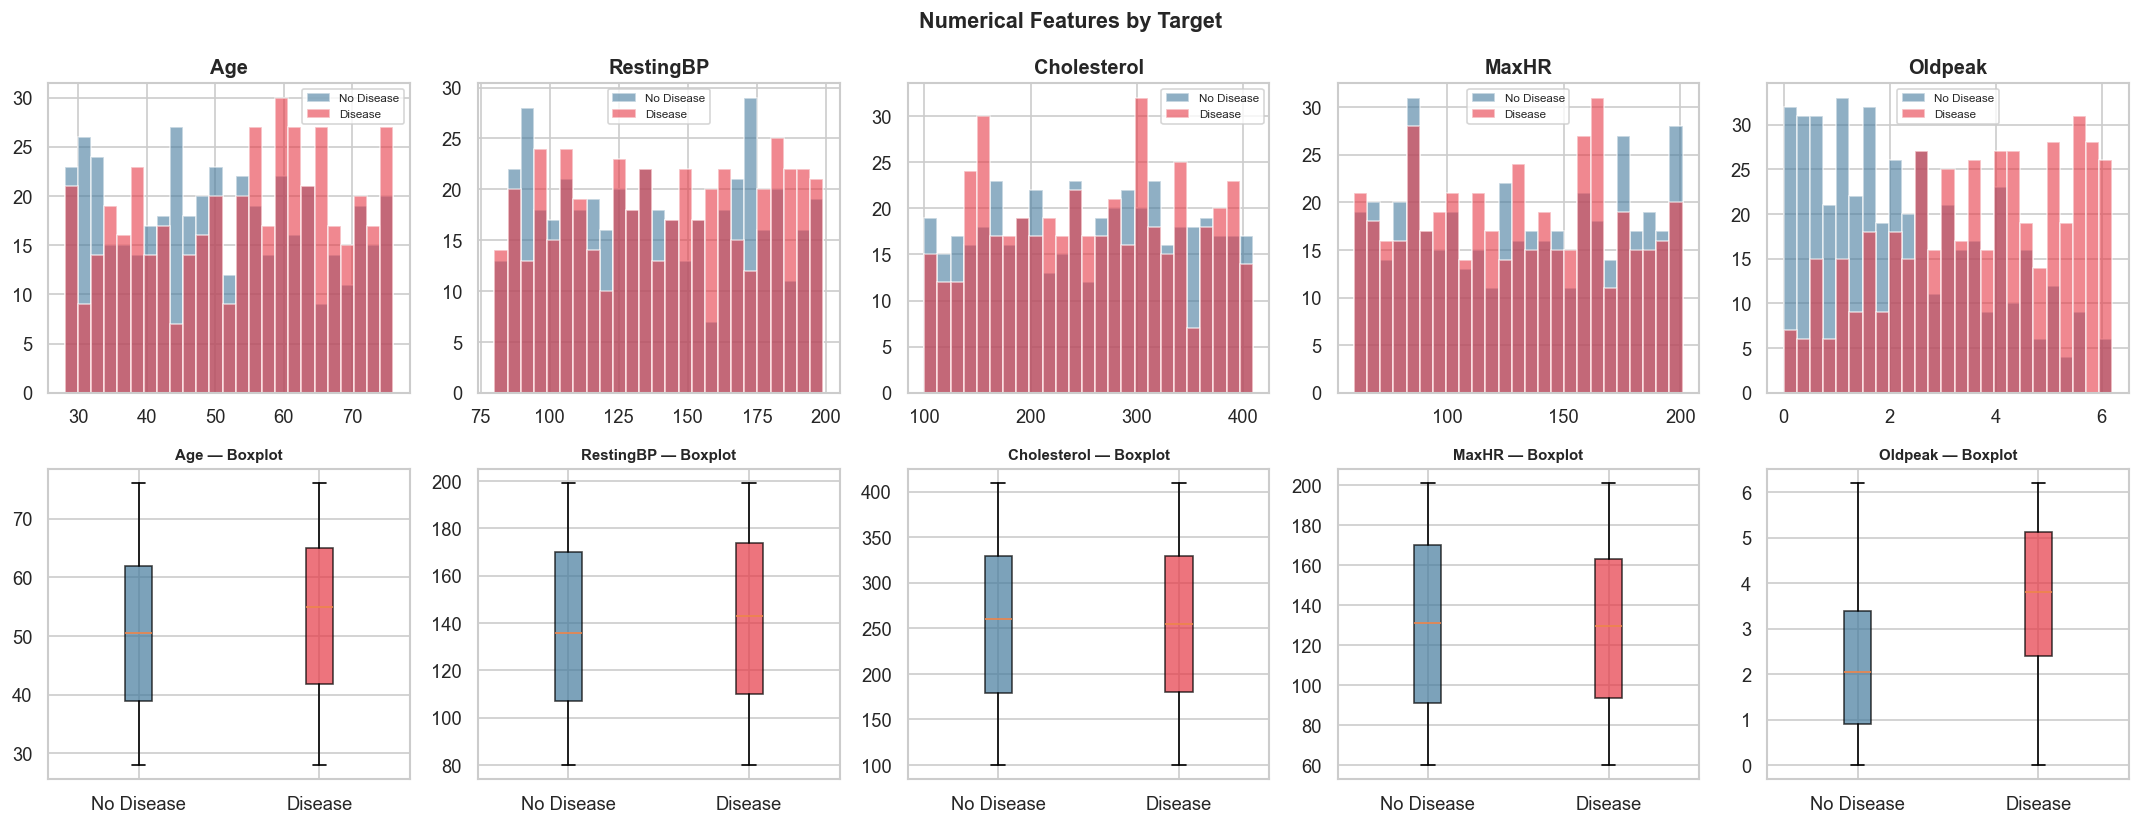

In [5]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0][i].hist(df[df['HeartDisease']==0][col], bins=25,
                    alpha=0.6, color='#457b9d', label='No Disease')
    axes[0][i].hist(df[df['HeartDisease']==1][col], bins=25,
                    alpha=0.6, color='#e63946', label='Disease')
    axes[0][i].set_title(col, fontweight='bold')
    axes[0][i].legend(fontsize=7)

    # Boxplot
    data_to_plot = [df[df['HeartDisease']==0][col].dropna(),
                    df[df['HeartDisease']==1][col].dropna()]
    bp = axes[1][i].boxplot(data_to_plot, patch_artist=True,
                             labels=['No Disease', 'Disease'])
    bp['boxes'][0].set_facecolor('#457b9d')
    bp['boxes'][1].set_facecolor('#e63946')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[1][i].set_title(f'{col} — Boxplot', fontweight='bold', fontsize=9)

plt.suptitle('Numerical Features by Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Categorical Features

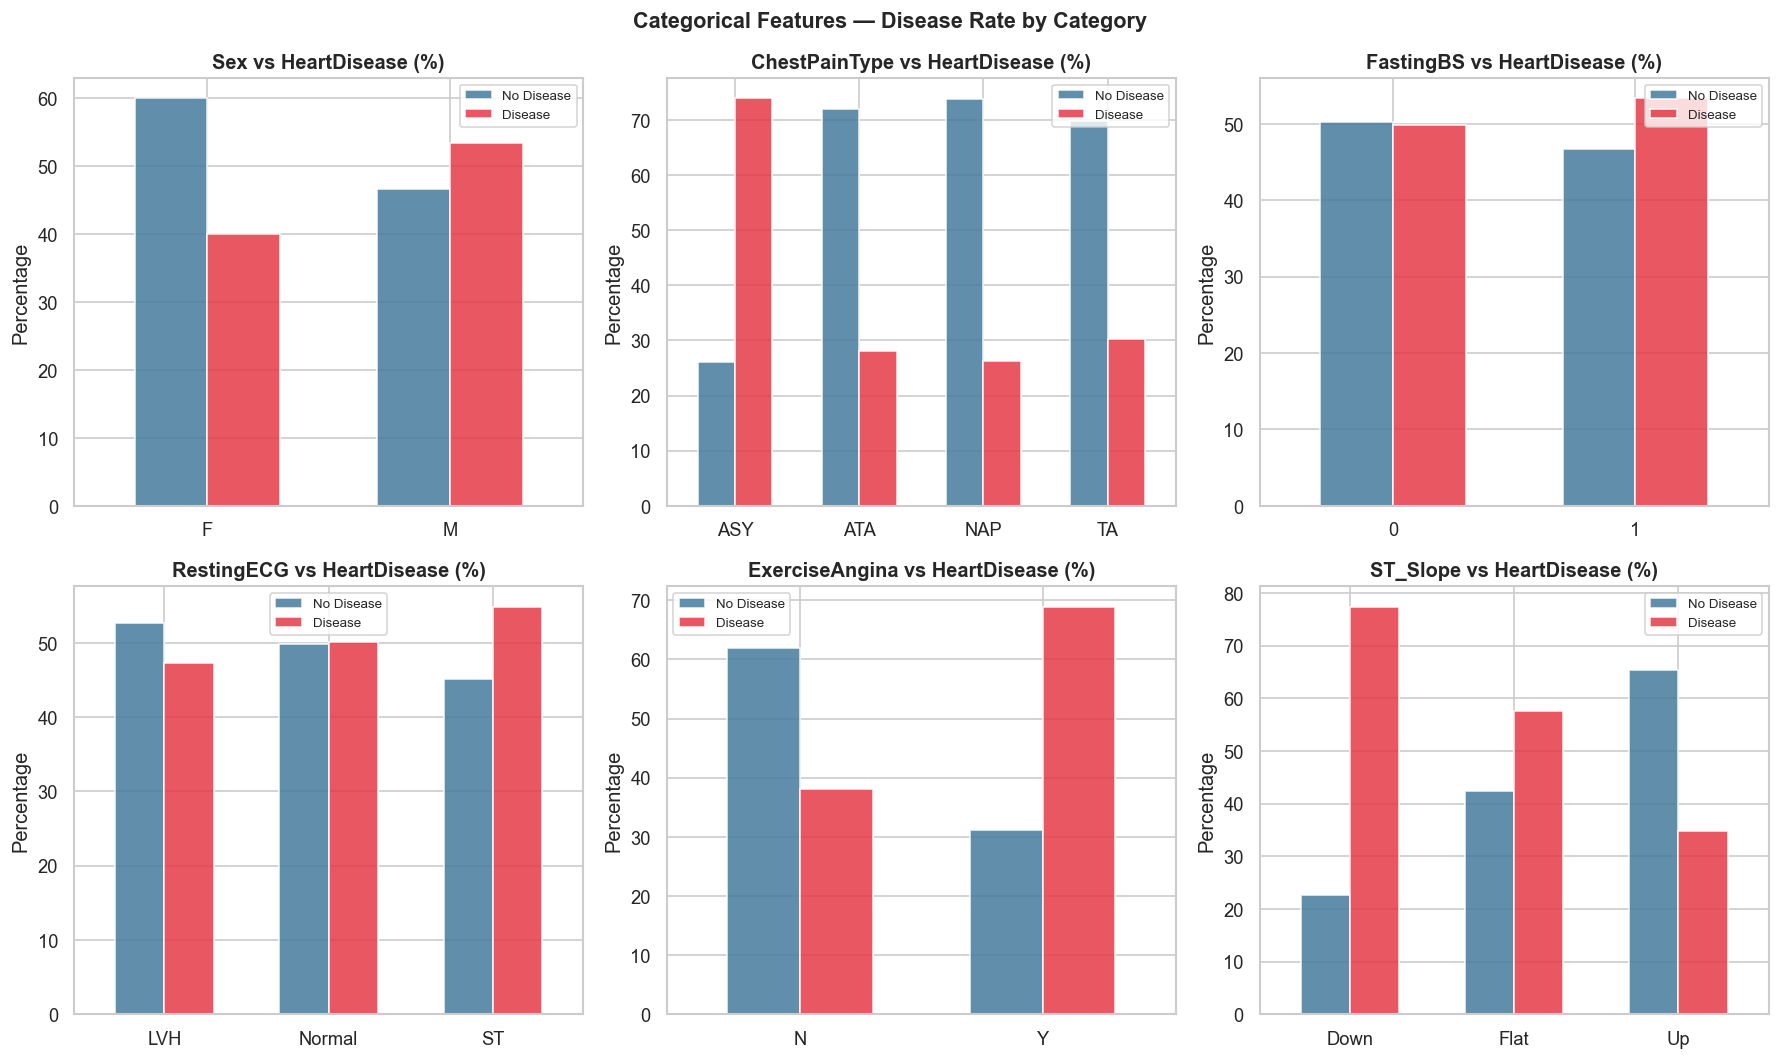

In [6]:
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#457b9d', '#e63946'],
            alpha=0.85, edgecolor='white', width=0.6)
    axes[i].set_title(f'{col} vs HeartDisease (%)', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features — Disease Rate by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

c:\Users\elssh\miniconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


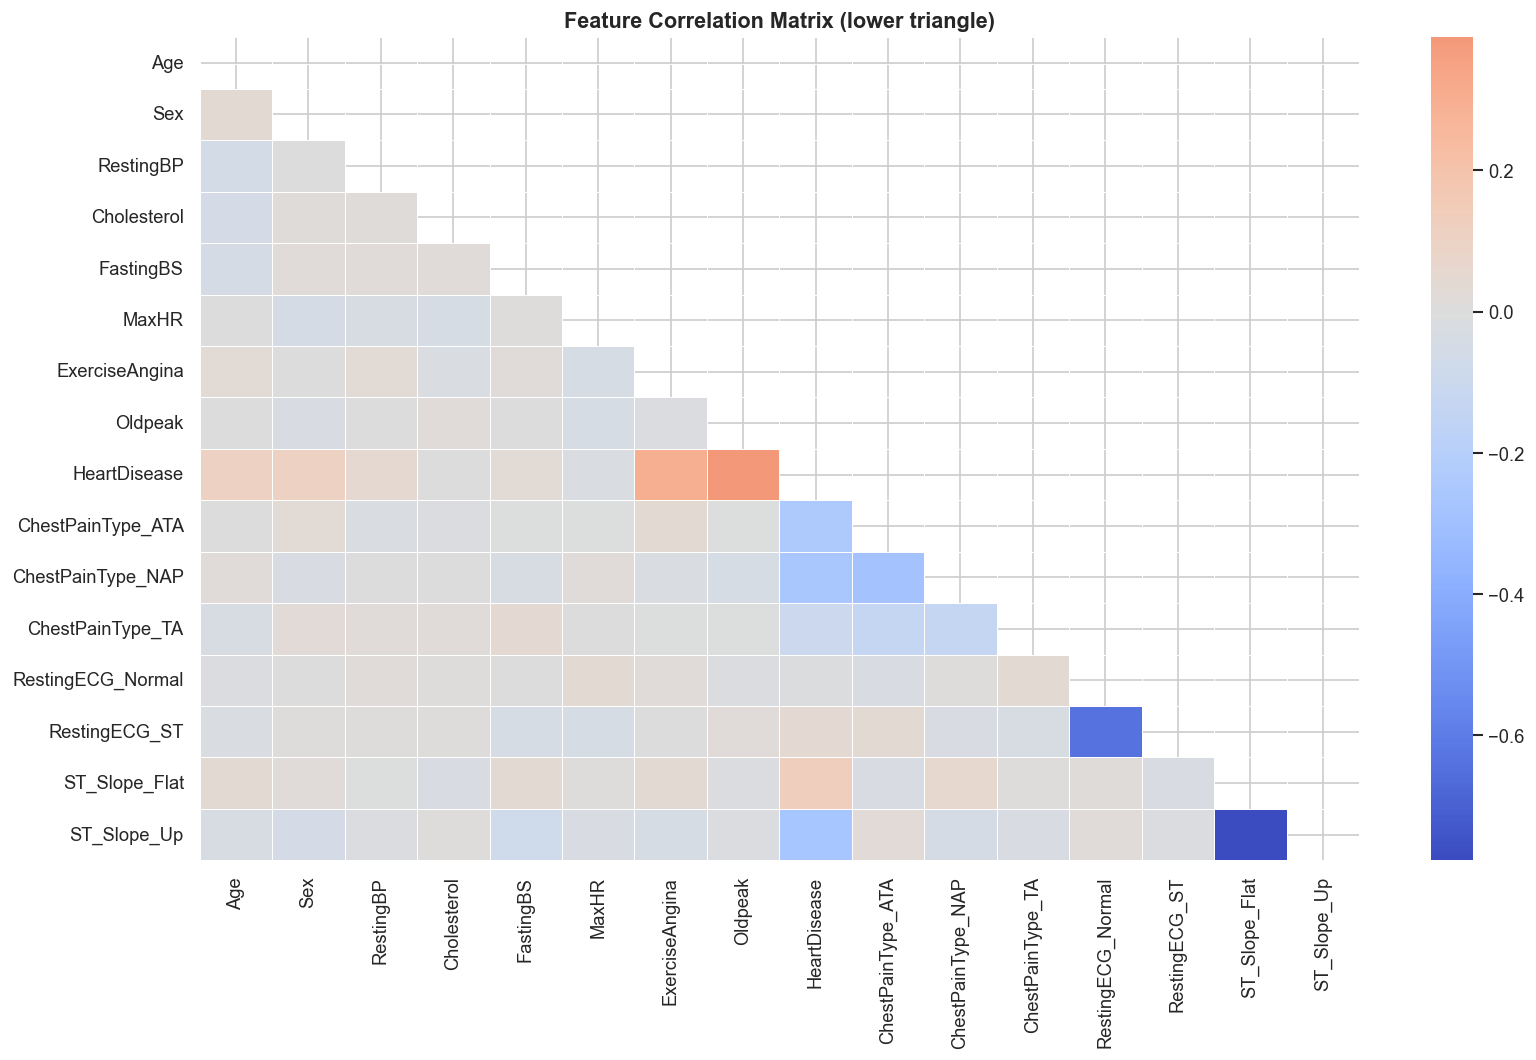

In [7]:
df_enc = df.copy()
df_enc['Sex'] = df_enc['Sex'].map({'M':1,'F':0})
df_enc['ExerciseAngina'] = df_enc['ExerciseAngina'].map({'Y':1,'N':0})
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType','RestingECG','ST_Slope'], drop_first=True)

fig, ax = plt.subplots(figsize=(14, 9))
mask = np.triu(np.ones_like(df_enc.corr(), dtype=bool))
sns.heatmap(df_enc.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Key Observations

In [8]:
print('=== Key Stats ===')
print(f"Dataset size     : {len(df)} patients")
print(f"Disease rate     : {df['HeartDisease'].mean():.1%}")
print(f"Mean age         : {df['Age'].mean():.1f} years")
print(f"Male proportion  : {(df['Sex']=='M').mean():.1%}")
print(f"\nDisease rate by sex:")
print(df.groupby('Sex')['HeartDisease'].mean().map('{:.1%}'.format))
print(f"\nDisease rate by ChestPainType:")
print(df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False).map('{:.1%}'.format))
print(f"\nDisease rate by ST_Slope:")
print(df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False).map('{:.1%}'.format))

=== Key Stats ===
Dataset size     : 918 patients
Disease rate     : 50.5%
Mean age         : 52.3 years
Male proportion  : 78.8%

Disease rate by sex:
Sex
F    40.0%
M    53.4%
Name: HeartDisease, dtype: object

Disease rate by ChestPainType:
ChestPainType
ASY    73.9%
TA     30.2%
ATA    28.0%
NAP    26.2%
Name: HeartDisease, dtype: object

Disease rate by ST_Slope:
ST_Slope
Down    77.4%
Flat    57.6%
Up      34.7%
Name: HeartDisease, dtype: object
